# Week 9 / Stage 5 — Focused β-VAE Ablation

## What it does
- trains a **small set of β-VAE models** on MNIST
- reuses a **fixed external digit classifier** and **fixed external thickness probe**
- evaluates **global** and **local** steering families for each β
- compares **fixed-step steering** and **automatic safe step selection** \(\alpha^*\)
- reports the trade-off between:
  - reconstruction quality,
  - KL regularization,
  - controllability,
  - content preservation,
  - and minimal-change / feature-drift proxies

In [1]:
%pip install -q torch torchvision matplotlib pandas tqdm scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import time
import math
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm
from IPython.display import Image, display

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg: Dict[str, Any] = {
    "seed": 42,
    "device": "cuda",

    "artifacts": {
        "digit_classifier_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/clf_best.pt",
        "thickness_probe_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/probe_best.pt",
    },

    "run": {
        "root": "runs",
        "tag": "week9_beta_vae",
    },

    "data": {
        "mnist_root": "../output/kaggle/working/data/MNIST/raw",
        "batch_size": 128,
        "num_workers": 0,
        "subset": None,   # e.g. 20000 for a faster debug run
    },

    "vae": {
        "latent_dim": 16,
        "lr": 1e-3,
        "epochs": 12,
        "betas": [1.0, 2.0, 4.0],
        "recon_loss": "bce",     # "bce" or "mse"
        "ckpt_every": 4,
    },

    "probe": {
        "aug": {
            "thin_k": 1,
            "thick_k": 1,
            "blend": 0.2,
        }
    },

    "cluster": {
        # Focused comparison: keep only one local family (best from prior weeks).
        "k_local": 8,
        "fit_max_points": 25000,
        "direction_max_batches": 250,
        "min_cluster_points": 32,
        "mbk_batch_size": 2048,
    },

    "steer": {
        "alphas": [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0],
        "preview_alphas": [0.0, 1.0, 2.0],
        "preview_n": 8,
    },

    "safe": {
        "alpha_grid": [0.0, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00],
        "tau_feat_values": [3.5, 5.0],
        "tau_conf": 0.10,
        "lambda_feat": 0.25,
        "lambda_conf": 0.50,
    },

    "selection": {
        "max_acc_drop_vs_recon": 0.02,
        "primary_tau_feat": 5.0,
    },
}

In [4]:
# ------------------------ helpers ------------------------

def get_device(name: str) -> torch.device:
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def save_json(path: str, obj: dict) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def make_run_dir(root: str, tag: str) -> str:
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{ts}_{tag}")
    os.makedirs(os.path.join(run_dir, "plots"), exist_ok=False)
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=True)
    return run_dir


def make_child_run_dir(parent: str, name: str) -> str:
    run_dir = os.path.join(parent, name)
    os.makedirs(os.path.join(run_dir, "plots"), exist_ok=True)
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=True)
    return run_dir


def require_existing_file(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"{name} was not found: {path}")
    return path


def prepare_dir_path(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    os.makedirs(path, exist_ok=True)
    return path


def get_mnist_loaders(
    data_root: str,
    batch_size: int,
    num_workers: int,
    subset: Optional[int] = None,
):
    from torchvision import datasets, transforms

    tfm = transforms.ToTensor()
    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=tfm)

    if subset is not None:
        subset = int(subset)
        train_ds = Subset(train_ds, list(range(subset)))
        test_ds = Subset(test_ds, list(range(min(subset // 5, len(test_ds)))))

    g = torch.Generator()
    g.manual_seed(int(cfg["seed"]))

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    return train_loader, test_loader


def format_beta(beta: float) -> str:
    s = f"{beta:.3f}".rstrip("0").rstrip(".")
    return s.replace(".", "p")


def extract_state_dict(obj: Any) -> Dict[str, torch.Tensor]:
    if isinstance(obj, dict):
        preferred = [
            "model_state", "state_dict", "model", "net",
            "vae_state", "clf_state", "probe_state",
            "vae", "clf", "probe",
        ]
        for k in preferred:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    if isinstance(obj, dict):
        return obj
    raise ValueError("Unsupported checkpoint format")


def load_module_checkpoint(module: nn.Module, ckpt_path: str, device: torch.device) -> nn.Module:
    obj = torch.load(ckpt_path, map_location=device)
    state = extract_state_dict(obj)
    missing, unexpected = module.load_state_dict(state, strict=False)
    if missing:
        print(f"[warn] missing keys when loading {ckpt_path}: {missing[:8]}")
    if unexpected:
        print(f"[warn] unexpected keys when loading {ckpt_path}: {unexpected[:8]}")
    return module


def to_numpy(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()


def mean_of_list(xs: List[float]) -> float:
    if len(xs) == 0:
        return float("nan")
    return float(np.mean(xs))

In [5]:
# ------------------------ models ------------------------
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_lv = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 64, 7, 7)
        return self.net(h)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.enc = ConvEncoder(latent_dim)
        self.dec = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparam(mu, lv)
        x_logits = self.dec(z)
        return x_logits, mu, lv


class DigitCNN(nn.Module):
    def __init__(self, feat_dim: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.fc1 = nn.Linear(64 * 7 * 7, feat_dim)
        self.fc2 = nn.Linear(feat_dim, 10)

    def forward(self, x, return_feat: bool = False):
        h = self.conv(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(feat)
        return (logits, feat) if return_feat else logits


class ThicknessProbe(nn.Module):
    def __init__(self, in_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
        )

    def forward(self, feat):
        return self.net(feat)

In [6]:
# ------------------------ VAE training + reconstruction metrics ------------------------
def vae_loss(
        x: torch.Tensor,
        x_logits: torch.Tensor,
        mu: torch.Tensor,
        logvar: torch.Tensor,
        beta: float = 1.0,
        recon: str = "bce",
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if recon == "bce":
        rec = F.binary_cross_entropy_with_logits(x_logits, x, reduction="sum") / x.size(0)
    elif recon == "mse":
        rec = F.mse_loss(torch.sigmoid(x_logits), x, reduction="sum") / x.size(0)
    else:
        raise ValueError(f"Unknown recon loss: {recon}")

    kl = 0.5 * torch.sum(mu.pow(2) + logvar.exp() - 1.0 - logvar, dim=1).mean()
    loss = rec + float(beta) * kl
    return loss, rec, kl

@torch.no_grad()
def save_recon_grid(
        model: nn.Module,
        loader: DataLoader,
        out_png: str,
        device: torch.device,
        n: int = 10,
    ):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    x_logits, _, _ = model(x)
    x_hat = torch.sigmoid(x_logits)

    grid = torch.cat([x.cpu(), x_hat.cpu()], dim=0).squeeze(1)
    cols, rows = n, 2
    plt.figure(figsize=(cols, rows * 1.2))
    for i in range(2 * n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(grid[i], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def plot_train_curves(
        hist: Dict[str, List[float]], 
        out_png: str, title: str
    ) -> None:
    plt.figure(figsize=(8, 5))
    for k in ["loss", "recon", "kl", "val_loss"]:
        if k in hist and len(hist[k]) > 0:
            plt.plot(hist[k], marker="o", label=k)
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def train_beta_vae(
        beta: float,
        train_loader: DataLoader,
        test_loader: DataLoader,
        device: torch.device,
        parent_run_dir: str,
    ) -> Tuple[nn.Module, Dict[str, Any], str]:
    beta_tag = format_beta(beta)
    beta_run_dir = make_child_run_dir(parent_run_dir, f"beta_{beta_tag}")

    model = ConvVAE(latent_dim=int(cfg["vae"]["latent_dim"])).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=float(cfg["vae"]["lr"]))

    epochs = int(cfg["vae"]["epochs"])
    recon = str(cfg["vae"]["recon_loss"])
    ckpt_every = int(cfg["vae"]["ckpt_every"])

    hist = {"loss": [], "recon": [], "kl": [], "val_loss": [], "val_recon": [], "val_kl": []}
    best_val = float("inf")
    best_path = os.path.join(beta_run_dir, "checkpoints", f"vae_beta_{beta_tag}_best.pt")
    last_path = os.path.join(beta_run_dir, "checkpoints", f"vae_beta_{beta_tag}_last.pt")

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = tr_rec = tr_kl = 0.0
        n_batches = 0

        for x, _ in tqdm(train_loader, desc=f"beta={beta} train ep{ep}", leave=False):
            x = x.to(device)
            x_logits, mu, lv = model(x)
            loss, rec, kl = vae_loss(x, x_logits, mu, lv, beta=beta, recon=recon)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            tr_loss += loss.item()
            tr_rec += rec.item()
            tr_kl += kl.item()
            n_batches += 1

        hist["loss"].append(tr_loss / max(1, n_batches))
        hist["recon"].append(tr_rec / max(1, n_batches))
        hist["kl"].append(tr_kl / max(1, n_batches))

        model.eval()
        va_loss = va_rec = va_kl = 0.0
        n_val = 0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_logits, mu, lv = model(x)
                loss, rec, kl = vae_loss(x, x_logits, mu, lv, beta=beta, recon=recon)
                va_loss += loss.item()
                va_rec += rec.item()
                va_kl += kl.item()
                n_val += 1

        val_loss = va_loss / max(1, n_val)
        hist["val_loss"].append(val_loss)
        hist["val_recon"].append(va_rec / max(1, n_val))
        hist["val_kl"].append(va_kl / max(1, n_val))

        if val_loss < best_val:
            best_val = val_loss
            torch.save({"model_state": model.state_dict(), "beta": beta, "epoch": ep}, best_path)

        if (ep % ckpt_every == 0) or (ep == epochs):
            torch.save({"model_state": model.state_dict(), "beta": beta, "epoch": ep}, last_path)
            save_recon_grid(
                model,
                test_loader,
                out_png=os.path.join(beta_run_dir, "plots", f"recon_beta_{beta_tag}_ep{ep}.png"),
                device=device,
                n=10,
            )

    plot_train_curves(
        hist,
        out_png=os.path.join(beta_run_dir, "plots", f"vae_beta_{beta_tag}_curves.png"),
        title=f"β-VAE training curves (beta={beta})",
    )

    model = load_module_checkpoint(ConvVAE(latent_dim=int(cfg["vae"]["latent_dim"])).to(device), best_path, device)
    model.eval()

    info = {
        "beta": float(beta),
        "beta_tag": beta_tag,
        "run_dir": beta_run_dir,
        "best_checkpoint": best_path,
        "last_checkpoint": last_path,
        "best_val_loss": float(best_val),
        "train_last_loss": float(hist["loss"][-1]),
        "train_last_recon": float(hist["recon"][-1]),
        "train_last_kl": float(hist["kl"][-1]),
        "val_last_loss": float(hist["val_loss"][-1]),
        "val_last_recon": float(hist["val_recon"][-1]),
        "val_last_kl": float(hist["val_kl"][-1]),
        "epochs": int(epochs),
    }
    save_json(os.path.join(beta_run_dir, "training_summary.json"), info)
    pd.DataFrame(hist).to_csv(os.path.join(beta_run_dir, "training_curve.csv"), index=False)

    return model, info, beta_run_dir

@torch.no_grad()
def evaluate_recon_baseline(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        beta: float,
        device: torch.device,
    ) -> Dict[str, float]:
    vae.eval()
    clf.eval()
    probe.eval()

    total = 0
    digit_correct = 0
    recon_bce = 0.0
    recon_mse = 0.0
    kl_sum = 0.0
    probe_margin_sum = 0.0
    p_thick_sum = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        x_logits, mu, lv = vae(x)
        x_rec = torch.sigmoid(x_logits)

        recon_bce += F.binary_cross_entropy(x_rec, x, reduction="sum").item() / x.size(0)
        recon_mse += F.mse_loss(x_rec, x, reduction="sum").item() / x.size(0)
        kl_sum += 0.5 * torch.sum(mu.pow(2) + lv.exp() - 1.0 - lv, dim=1).mean().item()

        logits_digit, feat = clf(x_rec, return_feat=True)
        pred_digit = logits_digit.argmax(dim=1)
        digit_correct += (pred_digit == y).sum().item()

        logits_probe = probe(feat)
        margin = logits_probe[:, 1] - logits_probe[:, 0]
        p_thick = torch.softmax(logits_probe, dim=1)[:, 1]

        probe_margin_sum += margin.sum().item()
        p_thick_sum += p_thick.sum().item()
        total += x.size(0)

    return {
        "beta": float(beta),
        "n": int(total),
        "digit_acc_recon": float(digit_correct / max(1, total)),
        "recon_bce_per_sample": float(recon_bce / max(1, len(loader))),
        "recon_mse_per_sample": float(recon_mse / max(1, len(loader))),
        "kl_per_sample": float(kl_sum / max(1, len(loader))),
        "probe_margin_recon": float(probe_margin_sum / max(1, total)),
        "probe_p_thick_recon": float(p_thick_sum / max(1, total)),
    }

In [7]:
# ------------------------ image / latent / steering utilities ------------------------
def gray_dilate(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = F.max_pool2d(out, kernel_size=k, stride=1, padding=pad)
    return out


def gray_erode(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = -F.max_pool2d(-out, kernel_size=k, stride=1, padding=pad)
    return out


def thickness_transform(x: torch.Tensor, mode: str, iters: int, blend: float) -> torch.Tensor:
    if mode == "thin":
        y = gray_erode(x, iters=iters)
    elif mode == "thick":
        y = gray_dilate(x, iters=iters)
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return torch.clamp((1.0 - blend) * x + blend * y, 0.0, 1.0)


def mean_ink(x: torch.Tensor) -> torch.Tensor:
    return x.flatten(1).mean(dim=1)


@torch.no_grad()
def encode_mu(vae: nn.Module, x: torch.Tensor) -> torch.Tensor:
    mu, _ = vae.enc(x)
    return mu


@torch.no_grad()
def decode_sigmoid(vae: nn.Module, z: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(vae.dec(z))


@torch.no_grad()
def clf_logits_and_feat(clf: nn.Module, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    return clf(x, return_feat=True)


def normalize_direction(d: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    n = float(np.linalg.norm(d))
    if n < eps:
        return d.astype(np.float32)
    return (d / n).astype(np.float32)


@torch.no_grad()
def extract_train_latents_and_deltas(
        vae: nn.Module,
        loader: DataLoader,
        thin_k: int,
        thick_k: int,
        blend: float,
        max_batches: Optional[int],
        device: torch.device,
    ) -> Dict[str, np.ndarray]:
    zs, deltas, ys = [], [], []
    ink_gap_sum = 0.0
    ink_n = 0

    for bi, (x, y) in enumerate(loader):
        if max_batches is not None and bi >= int(max_batches):
            break

        x = x.to(device)
        y = y.to(device)

        x_thin = thickness_transform(x, mode="thin", iters=thin_k, blend=blend)
        x_thick = thickness_transform(x, mode="thick", iters=thick_k, blend=blend)

        z = encode_mu(vae, x)
        z_thin = encode_mu(vae, x_thin)
        z_thick = encode_mu(vae, x_thick)

        zs.append(to_numpy(z))
        deltas.append(to_numpy(z_thick - z_thin))
        ys.append(to_numpy(y))

        ink_gap_sum += (mean_ink(x_thick) - mean_ink(x_thin)).sum().item()
        ink_n += x.size(0)

    Z = np.concatenate(zs, axis=0)
    D = np.concatenate(deltas, axis=0)
    Y = np.concatenate(ys, axis=0)

    return {
        "Z": Z.astype(np.float32),
        "D": D.astype(np.float32),
        "Y": Y.astype(np.int64),
        "ink_gap_mean": float(ink_gap_sum / max(1, ink_n)),
    }


def maybe_subsample(X: np.ndarray, max_points: Optional[int], seed: int) -> np.ndarray:
    if max_points is None or len(X) <= int(max_points):
        return np.arange(len(X))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_points), replace=False)
    return np.sort(idx)


def fit_direction_families(
        Z: np.ndarray,
        D: np.ndarray,
        k_local: int,
        fit_max_points: Optional[int],
        min_cluster_points: int,
        seed: int,
        mbk_batch_size: int,
    ) -> Tuple[Dict[str, Any], pd.DataFrame]:
    global_dir = normalize_direction(D.mean(axis=0))
    latent_dim = Z.shape[1]

    families: Dict[str, Any] = {
        "global": {
            "type": "global",
            "name": "global",
            "direction": global_dir,
            "latent_dim": latent_dim,
            "num_points": int(len(Z)),
        }
    }

    fit_idx = maybe_subsample(Z, fit_max_points, seed=seed)
    Z_fit = Z[fit_idx]
    km = MiniBatchKMeans(
        n_clusters=int(k_local),
        random_state=int(seed),
        batch_size=int(mbk_batch_size),
        n_init="auto",
    )
    km.fit(Z_fit)
    assign = km.predict(Z)

    dirs = np.zeros((int(k_local), latent_dim), dtype=np.float32)
    cluster_rows = []
    fallback_count = 0

    for k in range(int(k_local)):
        mask = assign == k
        n_k = int(mask.sum())
        if n_k < int(min_cluster_points):
            dirs[k] = global_dir
            fallback_count += 1
            used_fallback = 1
        else:
            d_k = D[mask].mean(axis=0)
            if float(np.linalg.norm(d_k)) < 1e-8:
                dirs[k] = global_dir
                fallback_count += 1
                used_fallback = 1
            else:
                dirs[k] = normalize_direction(d_k)
                used_fallback = 0

        cluster_rows.append(
            {
                "K": int(k_local),
                "cluster": int(k),
                "n_points": n_k,
                "direction_norm": float(np.linalg.norm(dirs[k])),
                "used_global_fallback": int(used_fallback),
            }
        )

    families[f"local_k{k_local}"] = {
        "type": "local",
        "name": f"local_k{k_local}",
        "K": int(k_local),
        "kmeans": km,
        "directions": dirs,
        "fallback_count": int(fallback_count),
        "latent_dim": latent_dim,
        "num_points": int(len(Z)),
    }
    return families, pd.DataFrame(cluster_rows)


def assign_local_directions(family: Dict[str, Any], z_batch: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    z_np = to_numpy(z_batch)
    cluster_ids = family["kmeans"].predict(z_np)
    dirs_np = family["directions"][cluster_ids]
    return torch.from_numpy(dirs_np).to(z_batch.device), torch.from_numpy(cluster_ids).to(z_batch.device)


def safe_spearman_per_sample(alphas: List[float], margins_a_by_b: np.ndarray) -> np.ndarray:
    try:
        from scipy.stats import spearmanr
        vals = []
        a = np.asarray(alphas)
        for b in range(margins_a_by_b.shape[1]):
            m = margins_a_by_b[:, b]
            if np.allclose(m, m[0]):
                vals.append(0.0)
            else:
                vals.append(float(spearmanr(a, m).statistic))
        return np.asarray(vals, dtype=np.float32)
    except Exception:
        a = np.asarray(alphas)
        ra = pd.Series(a).rank(method="average").to_numpy()
        out = []
        for b in range(margins_a_by_b.shape[1]):
            m = margins_a_by_b[:, b]
            if np.allclose(m, m[0]):
                out.append(0.0)
            else:
                rm = pd.Series(m).rank(method="average").to_numpy()
                c = np.corrcoef(ra, rm)[0, 1]
                out.append(float(0.0 if np.isnan(c) else c))
        return np.asarray(out, dtype=np.float32)

In [14]:
# ------------------------ fixed-step and auto-alpha evaluation ------------------------
@torch.no_grad()
def evaluate_fixed(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        alphas: List[float],
        beta: float,
        device: torch.device,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # rows: one row per family x alpha for this beta
    rows = []
    # summary_rows: family-level summary for this beta
    summary_rows = []

    for family_name, family in families.items():
        for alpha in alphas:
            rows.append(
                {
                    "beta": float(beta),
                    "family": family_name,
                    "family_type": family["type"],
                    "K": int(family.get("K", 0)),
                    "alpha": float(alpha),
                    "n": 0,
                    "digit_acc_sum": 0.0,
                    "digit_consistency_sum": 0.0,
                    "probe_margin_sum": 0.0,
                    "probe_margin_gain_sum": 0.0,
                    "probe_p_thick_sum": 0.0,
                    "feat_l2_to_recon_sum": 0.0,
                    "conf_drop_sum": 0.0,
                    "feasible_tau35_sum": 0.0,
                    "feasible_tau50_sum": 0.0,
                }
            )

    # Fast lookup for row updates
    row_index = {(r["family"], r["alpha"]): i for i, r in enumerate(rows)}

    # Placeholder for family-level extra stats (e.g. monotonicity)
    family_state = {name: {"alpha_to_margin_list": {float(a): [] for a in alphas}} for name in families.keys()}

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # Encode originals and decode plain reconstructions
        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)

        # Reconstruction acts as reference state
        recon_logits, recon_feat = clf_logits_and_feat(clf, x_rec)
        recon_pred = recon_logits.argmax(dim=1)
        recon_prob = torch.softmax(recon_logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1)

        # Thickness baseline on reconstruction
        recon_probe_logits = probe(recon_feat)
        recon_margin = recon_probe_logits[:, 1] - recon_probe_logits[:, 0]

        for family_name, family in families.items():
            # Global family: same direction for all; local: cluster-specific
            if family["type"] == "global":
                d_batch = torch.from_numpy(family["direction"]).to(device).unsqueeze(0).expand_as(z)
            else:
                d_batch, _ = assign_local_directions(family, z)

            # Store margin(alpha) curve for this batch/family
            margin_curve_list = []

            for alpha in alphas:
                # Apply steering step in latent space
                z_s = z + float(alpha) * d_batch
                x_s = decode_sigmoid(vae, z_s)

                # Evaluate edited reconstruction
                logits_digit, feat_s = clf_logits_and_feat(clf, x_s)
                logits_probe = probe(feat_s)

                pred_digit = logits_digit.argmax(dim=1)

                # Drop in confidence for the true class
                p_true = torch.softmax(logits_digit, dim=1).gather(1, y.view(-1, 1)).squeeze(1)
                conf_drop = torch.clamp(recon_prob - p_true, min=0.0)

                # Main steering metrics
                margin = logits_probe[:, 1] - logits_probe[:, 0]
                p_thick = torch.softmax(logits_probe, dim=1)[:, 1]
                feat_l2 = torch.norm(feat_s - recon_feat, dim=1)
                margin_gain = margin - recon_margin

                # Update the correct family x alpha row
                idx = row_index[(family_name, float(alpha))]
                rows[idx]["n"] += int(x.size(0))
                rows[idx]["digit_acc_sum"] += (pred_digit == y).sum().item()
                rows[idx]["digit_consistency_sum"] += (pred_digit == recon_pred).sum().item()
                rows[idx]["probe_margin_sum"] += margin.sum().item()
                rows[idx]["probe_margin_gain_sum"] += margin_gain.sum().item()
                rows[idx]["probe_p_thick_sum"] += p_thick.sum().item()
                rows[idx]["feat_l2_to_recon_sum"] += feat_l2.sum().item()
                rows[idx]["conf_drop_sum"] += conf_drop.sum().item()

                # Feasibility under two fixed feature budgets
                rows[idx]["feasible_tau35_sum"] += ((feat_l2 <= 3.5) & (conf_drop <= float(cfg["safe"]["tau_conf"]))).sum().item()
                rows[idx]["feasible_tau50_sum"] += ((feat_l2 <= 5.0) & (conf_drop <= float(cfg["safe"]["tau_conf"]))).sum().item()

                margin_curve_list.append(to_numpy(margin))

            # Batch-level monotonicity curve over alpha
            margin_curve_arr = np.stack(margin_curve_list, axis=0)
            corr = safe_spearman_per_sample(alphas, margin_curve_arr)

            # Currently saved only as a placeholder entry
            family_state[family_name]["alpha_to_margin_list"][float(alphas[0])].append(corr)

    df = pd.DataFrame(rows)

    # Convert sums to means
    for col_sum, col_out in [
        ("digit_acc_sum", "digit_acc"),
        ("digit_consistency_sum", "digit_consistency"),
        ("probe_margin_sum", "probe_margin"),
        ("probe_margin_gain_sum", "probe_margin_gain"),
        ("probe_p_thick_sum", "probe_p_thick"),
        ("feat_l2_to_recon_sum", "feat_l2_to_recon"),
        ("conf_drop_sum", "conf_drop"),
        ("feasible_tau35_sum", "feasible_rate_tau35"),
        ("feasible_tau50_sum", "feasible_rate_tau50"),
    ]:
        df[col_out] = df[col_sum] / df["n"].clip(lower=1)

    # Keep only final output columns
    keep_cols = [
        "beta", "family", "family_type", "K", "alpha", "n",
        "digit_acc", "digit_consistency",
        "probe_margin", "probe_margin_gain", "probe_p_thick",
        "feat_l2_to_recon", "conf_drop",
        "feasible_rate_tau35", "feasible_rate_tau50",
    ]
    df = df[keep_cols].sort_values(["beta", "family", "alpha"]).reset_index(drop=True)

    # Family-level summary table
    for family_name in families.keys():
        fam_df = df[df["family"] == family_name].sort_values("alpha")
        margin_mat = []
        # Monotonicity is not fully reconstructed here yet, so keep NaN
        summary_rows.append(
            {
                "beta": float(beta),
                "family": family_name,
                "family_type": families[family_name]["type"],
                "K": int(families[family_name].get("K", 0)),
                "mean_monotonicity": float("nan"),
                "n_points_train": int(families[family_name]["num_points"]),
            }
        )

    return df, pd.DataFrame(summary_rows)


def summarize_best_positive_alpha(
        df_fixed: pd.DataFrame,
        recon_df: pd.DataFrame,
        max_acc_drop_vs_recon: float,
    ) -> pd.DataFrame:
    # Pick best positive alpha per beta/family under an accuracy-drop budget
    rows = []
    for beta, dfb in df_fixed.groupby("beta"):
        recon_acc = float(recon_df.loc[recon_df["beta"] == beta, "digit_acc_recon"].iloc[0])
        allowed_min_acc = recon_acc - float(max_acc_drop_vs_recon)

        for family, g in dfb.groupby("family"):
            g = g[g["alpha"] > 0].copy()
            g = g[g["digit_acc"] >= allowed_min_acc].copy()
            if len(g) == 0:
                continue

            # Best fixed alpha = largest gain, then largest digit accuracy
            best = g.sort_values(["probe_margin_gain", "digit_acc"], ascending=[False, False]).iloc[0]
            rows.append(
                {
                    "beta": float(beta),
                    "family": str(family),
                    "best_fixed_alpha": float(best["alpha"]),
                    "digit_acc": float(best["digit_acc"]),
                    "digit_consistency": float(best["digit_consistency"]),
                    "probe_margin_gain": float(best["probe_margin_gain"]),
                    "feat_l2_to_recon": float(best["feat_l2_to_recon"]),
                    "conf_drop": float(best["conf_drop"]),
                    "feasible_rate_tau35": float(best["feasible_rate_tau35"]),
                    "feasible_rate_tau50": float(best["feasible_rate_tau50"]),
                }
            )
    return pd.DataFrame(rows)


@torch.no_grad()
def evaluate_auto_alpha(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        alpha_grid: List[float],
        tau_feat_values: List[float],
        tau_conf: float,
        lambda_feat: float,
        lambda_conf: float,
        beta: float,
        device: torch.device,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # rows: summary per beta x family x tau_feat
    rows = []
    # sample_rows: per-sample chosen alpha* and outcomes
    sample_rows = []

    for family_name, family in families.items():
        for tau_feat in tau_feat_values:
            rows.append(
                {
                    "beta": float(beta),
                    "family": family_name,
                    "family_type": family["type"],
                    "K": int(family.get("K", 0)),
                    "tau_feat": float(tau_feat),
                    "tau_conf": float(tau_conf),
                    "n": 0,
                    "digit_acc_sum": 0.0,
                    "digit_consistency_sum": 0.0,
                    "probe_margin_gain_sum": 0.0,
                    "feat_l2_to_recon_sum": 0.0,
                    "conf_drop_sum": 0.0,
                    "alpha_star_sum": 0.0,
                    "nonzero_sum": 0.0,
                    "objective_sum": 0.0,
                }
            )

    # Fast lookup for row updates
    row_index = {(r["family"], r["tau_feat"]): i for i, r in enumerate(rows)}

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # Base latent and plain reconstruction
        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)
        recon_logits, recon_feat = clf_logits_and_feat(clf, x_rec)
        recon_pred = recon_logits.argmax(dim=1)
        recon_prob = torch.softmax(recon_logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1)
        recon_probe_logits = probe(recon_feat)
        recon_margin = recon_probe_logits[:, 1] - recon_probe_logits[:, 0]

        batch_size = x.size(0)

        for family_name, family in families.items():
            # Get direction batch for the chosen family
            if family["type"] == "global":
                d_batch = torch.from_numpy(family["direction"]).to(device).unsqueeze(0).expand_as(z)
            else:
                d_batch, _ = assign_local_directions(family, z)

            # Precompute edited metrics for every alpha on this batch
            alpha_metrics = []
            for alpha in alpha_grid:
                z_s = z + float(alpha) * d_batch
                x_s = decode_sigmoid(vae, z_s)

                logits_digit, feat_s = clf_logits_and_feat(clf, x_s)
                logits_probe = probe(feat_s)

                pred_digit = logits_digit.argmax(dim=1)

                # Confidence drop relative to reconstruction baseline
                p_true = torch.softmax(logits_digit, dim=1).gather(1, y.view(-1, 1)).squeeze(1)
                conf_drop = torch.clamp(recon_prob - p_true, min=0.0)

                # Main steering metrics for this alpha
                margin = logits_probe[:, 1] - logits_probe[:, 0]
                margin_gain = margin - recon_margin
                feat_l2 = torch.norm(feat_s - recon_feat, dim=1)

                # Feasibility under the loosest tau in the grid
                feasible = (feat_l2 <= float(max(tau_feat_values))) & (conf_drop <= float(tau_conf))

                # Soft objective for alpha* selection
                objective = margin_gain - float(lambda_feat) * feat_l2 - float(lambda_conf) * conf_drop

                alpha_metrics.append(
                    {
                        "alpha": float(alpha),
                        "pred_digit": pred_digit,
                        "margin_gain": margin_gain,
                        "feat_l2": feat_l2,
                        "conf_drop": conf_drop,
                        "objective": objective,
                    }
                )

            for tau_feat in tau_feat_values:
                # Best-so-far alpha* for each sample in this batch
                best_alpha = torch.zeros(batch_size, device=device)
                best_obj = torch.full((batch_size,), -1e9, device=device)
                best_pred = recon_pred.clone()
                best_margin_gain = torch.zeros(batch_size, device=device)
                best_feat_l2 = torch.zeros(batch_size, device=device)
                best_conf_drop = torch.zeros(batch_size, device=device)

                for item in alpha_metrics:
                    alpha = float(item["alpha"])

                    # Candidate alpha must satisfy current budgets
                    feasible = (item["feat_l2"] <= float(tau_feat)) & (item["conf_drop"] <= float(tau_conf))
                    better = feasible & (item["objective"] > best_obj)

                    # Update alpha* where current alpha is better
                    best_obj = torch.where(better, item["objective"], best_obj)
                    best_alpha = torch.where(better, torch.full_like(best_alpha, alpha), best_alpha)
                    best_pred = torch.where(better, item["pred_digit"], best_pred)
                    best_margin_gain = torch.where(better, item["margin_gain"], best_margin_gain)
                    best_feat_l2 = torch.where(better, item["feat_l2"], best_feat_l2)
                    best_conf_drop = torch.where(better, item["conf_drop"], best_conf_drop)

                idx = row_index[(family_name, float(tau_feat))]
                rows[idx]["n"] += int(batch_size)
                rows[idx]["digit_acc_sum"] += (best_pred == y).sum().item()
                rows[idx]["digit_consistency_sum"] += (best_pred == recon_pred).sum().item()
                rows[idx]["probe_margin_gain_sum"] += best_margin_gain.sum().item()
                rows[idx]["feat_l2_to_recon_sum"] += best_feat_l2.sum().item()
                rows[idx]["conf_drop_sum"] += best_conf_drop.sum().item()
                rows[idx]["alpha_star_sum"] += best_alpha.sum().item()
                rows[idx]["nonzero_sum"] += (best_alpha > 0).sum().item()
                rows[idx]["objective_sum"] += best_obj.sum().item()

                # Save per-sample choices for histograms/failure analysis
                sample_rows.append(
                    pd.DataFrame(
                        {
                            "beta": float(beta),
                            "family": family_name,
                            "tau_feat": float(tau_feat),
                            "digit_ok": to_numpy((best_pred == y).float()),
                            "digit_consistency": to_numpy((best_pred == recon_pred).float()),
                            "probe_margin_gain": to_numpy(best_margin_gain),
                            "feat_l2_to_recon": to_numpy(best_feat_l2),
                            "conf_drop": to_numpy(best_conf_drop),
                            "alpha_star": to_numpy(best_alpha),
                            "objective": to_numpy(best_obj),
                        }
                    )
                )

    df = pd.DataFrame(rows)

    # Convert sums to averaged metrics
    df["digit_acc"] = df["digit_acc_sum"] / df["n"].clip(lower=1)
    df["digit_consistency"] = df["digit_consistency_sum"] / df["n"].clip(lower=1)
    df["probe_margin_gain"] = df["probe_margin_gain_sum"] / df["n"].clip(lower=1)
    df["feat_l2_to_recon"] = df["feat_l2_to_recon_sum"] / df["n"].clip(lower=1)
    df["conf_drop"] = df["conf_drop_sum"] / df["n"].clip(lower=1)
    df["mean_alpha_star"] = df["alpha_star_sum"] / df["n"].clip(lower=1)
    df["alpha_nonzero_rate"] = df["nonzero_sum"] / df["n"].clip(lower=1)
    df["mean_objective"] = df["objective_sum"] / df["n"].clip(lower=1)

    # By construction, alpha=0 remains a feasible fallback
    df["feasible_rate"] = 1.0

    keep_cols = [
        "beta", "family", "family_type", "K", "tau_feat", "tau_conf", "n",
        "digit_acc", "digit_consistency", "probe_margin_gain",
        "feat_l2_to_recon", "conf_drop",
        "mean_alpha_star", "alpha_nonzero_rate",
        "mean_objective", "feasible_rate",
    ]
    df = df[keep_cols].sort_values(["beta", "family", "tau_feat"]).reset_index(drop=True)

    df_samples = pd.concat(sample_rows, axis=0, ignore_index=True) if len(sample_rows) > 0 else pd.DataFrame()
    return df, df_samples


def summarize_best_auto(
        df_auto: pd.DataFrame,
        primary_tau_feat: float,
    ) -> pd.DataFrame:
    # Keep only the main tau_feat used for reporting
    g = df_auto[np.isclose(df_auto["tau_feat"], float(primary_tau_feat))].copy()
    if len(g) == 0:
        return pd.DataFrame()

    rows = []
    for beta, dfb in g.groupby("beta"):
        # Best auto setting per beta = largest gain, then largest accuracy
        best = dfb.sort_values(["probe_margin_gain", "digit_acc"], ascending=[False, False]).iloc[0]
        rows.append(
            {
                "beta": float(beta),
                "family": str(best["family"]),
                "tau_feat": float(best["tau_feat"]),
                "digit_acc": float(best["digit_acc"]),
                "digit_consistency": float(best["digit_consistency"]),
                "probe_margin_gain": float(best["probe_margin_gain"]),
                "feat_l2_to_recon": float(best["feat_l2_to_recon"]),
                "conf_drop": float(best["conf_drop"]),
                "mean_alpha_star": float(best["mean_alpha_star"]),
                "alpha_nonzero_rate": float(best["alpha_nonzero_rate"]),
                "mean_objective": float(best["mean_objective"]),
            }
        )
        
    return pd.DataFrame(rows)

In [15]:
# ------------------------ plots + memo ------------------------
def plot_beta_recon_summary(df_recon: pd.DataFrame, out_png: str) -> None:
    betas = df_recon["beta"].astype(float).to_numpy()
    plt.figure(figsize=(8, 5.5))
    plt.plot(betas, df_recon["recon_bce_per_sample"], marker="o", label="recon_bce")
    plt.plot(betas, df_recon["kl_per_sample"], marker="o", label="kl")
    plt.plot(betas, df_recon["digit_acc_recon"], marker="o", label="digit_acc_recon")
    plt.xlabel("beta")
    plt.title("β-VAE baseline trade-off")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def plot_beta_fixed_vs_auto(df_fixed_best: pd.DataFrame, df_auto_best: pd.DataFrame, out_png: str) -> None:
    plt.figure(figsize=(8, 5.8))
    if len(df_fixed_best) > 0:
        plt.scatter(
            df_fixed_best["feat_l2_to_recon"],
            df_fixed_best["probe_margin_gain"],
            label="best fixed",
            marker="o",
            s=80,
        )
        for _, r in df_fixed_best.iterrows():
            plt.text(r["feat_l2_to_recon"], r["probe_margin_gain"], f"β={r['beta']}, {r['family']}", fontsize=8)

    if len(df_auto_best) > 0:
        plt.scatter(
            df_auto_best["feat_l2_to_recon"],
            df_auto_best["probe_margin_gain"],
            label="best auto",
            marker="^",
            s=90,
        )
        for _, r in df_auto_best.iterrows():
            plt.text(r["feat_l2_to_recon"], r["probe_margin_gain"], f"β={r['beta']}, {r['family']}", fontsize=8)

    plt.xlabel("feature drift to recon (lower is better)")
    plt.ylabel("probe margin gain (higher is better)")
    plt.title("Best steering trade-off by beta")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def plot_beta_auto_reliability(df_auto: pd.DataFrame, primary_tau_feat: float, out_png: str) -> None:
    g = df_auto[np.isclose(df_auto["tau_feat"], float(primary_tau_feat))].copy()
    plt.figure(figsize=(8, 5.5))
    for family, dff in g.groupby("family"):
        dff = dff.sort_values("beta")
        plt.plot(dff["beta"], dff["digit_consistency"], marker="o", label=f"{family}: consistency")
        plt.plot(dff["beta"], dff["alpha_nonzero_rate"], marker="s", linestyle="--", label=f"{family}: nonzero α*")
    plt.xlabel("beta")
    plt.ylabel("rate")
    plt.title(f"Auto steering reliability at tau_feat={primary_tau_feat}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

@torch.no_grad()
def save_preview_best_auto_per_beta(
        vae_models: Dict[float, nn.Module],
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        best_auto_df: pd.DataFrame,
        families_by_beta: Dict[float, Dict[str, Any]],
        out_png: str,
        device: torch.device,
        n: int = 6,
    ):
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n].to(device)

    betas = sorted(list(vae_models.keys()))
    rows = len(betas)
    cols = n * 3

    plt.figure(figsize=(cols * 0.8, rows * 2.2))

    for bi, beta in enumerate(betas):
        vae = vae_models[beta]
        row = best_auto_df[best_auto_df["beta"] == beta].iloc[0]
        family_name = str(row["family"])
        tau_feat = float(row["tau_feat"])
        family = families_by_beta[beta][family_name]

        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)
        recon_logits, recon_feat = clf_logits_and_feat(clf, x_rec)
        recon_prob = torch.softmax(recon_logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1)
        recon_probe_logits = probe(recon_feat)
        recon_margin = recon_probe_logits[:, 1] - recon_probe_logits[:, 0]

        if family["type"] == "global":
            d_batch = torch.from_numpy(family["direction"]).to(device).unsqueeze(0).expand_as(z)
        else:
            d_batch, _ = assign_local_directions(family, z)

        chosen_alpha = torch.zeros(x.size(0), device=device)
        chosen_xs = x_rec.clone()
        chosen_obj = torch.full((x.size(0),), -1e9, device=device)

        for alpha in cfg["safe"]["alpha_grid"]:
            z_s = z + float(alpha) * d_batch
            x_s = decode_sigmoid(vae, z_s)
            logits_digit, feat_s = clf_logits_and_feat(clf, x_s)
            logits_probe = probe(feat_s)

            p_true = torch.softmax(logits_digit, dim=1).gather(1, y.view(-1, 1)).squeeze(1)
            conf_drop = torch.clamp(recon_prob - p_true, min=0.0)
            margin = logits_probe[:, 1] - logits_probe[:, 0]
            margin_gain = margin - recon_margin
            feat_l2 = torch.norm(feat_s - recon_feat, dim=1)
            feasible = (feat_l2 <= tau_feat) & (conf_drop <= float(cfg["safe"]["tau_conf"]))
            obj = margin_gain - float(cfg["safe"]["lambda_feat"]) * feat_l2 - float(cfg["safe"]["lambda_conf"]) * conf_drop

            better = feasible & (obj > chosen_obj)
            chosen_obj = torch.where(better, obj, chosen_obj)
            chosen_alpha = torch.where(better, torch.full_like(chosen_alpha, float(alpha)), chosen_alpha)
            chosen_xs = torch.where(better[:, None, None, None], x_s, chosen_xs)

        for i in range(n):
            # original
            plt.subplot(rows, cols, bi * cols + 3 * i + 1)
            plt.imshow(x[i].detach().cpu().squeeze(0), cmap="gray")
            plt.title(f"β={beta}\norig", fontsize=8)
            plt.axis("off")
            # recon
            plt.subplot(rows, cols, bi * cols + 3 * i + 2)
            plt.imshow(x_rec[i].detach().cpu().squeeze(0), cmap="gray")
            plt.title("recon", fontsize=8)
            plt.axis("off")
            # steered
            plt.subplot(rows, cols, bi * cols + 3 * i + 3)
            plt.imshow(chosen_xs[i].detach().cpu().squeeze(0), cmap="gray")
            plt.title(f"α*={chosen_alpha[i].item():.2f}", fontsize=8)
            plt.axis("off")

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def write_week9_memo(
        run_dir: str,
        cfg: Dict[str, Any],
        df_recon: pd.DataFrame,
        df_fixed_best: pd.DataFrame,
        df_auto_best: pd.DataFrame,
    ) -> None:
    lines = []
    lines.append("# Week 9 — Weekly Update (1 page)")
    lines.append("")
    lines.append("## Goal")
    lines.append("Run a focused β-VAE comparison to test whether stronger KL regularization improves steering controllability, consistency, and safety, while explicitly reporting the reconstruction trade-off.")
    lines.append("")
    lines.append("## What I ran")
    lines.append(f"- betas: {cfg['vae']['betas']}")
    lines.append(f"- latent_dim: {cfg['vae']['latent_dim']}")
    lines.append(f"- epochs per beta: {cfg['vae']['epochs']}")
    lines.append(f"- steering families: global + local_k{cfg['cluster']['k_local']}")
    lines.append(f"- auto alpha grid: {cfg['safe']['alpha_grid']}")
    lines.append(f"- feature budgets: {cfg['safe']['tau_feat_values']}")
    lines.append("")

    lines.append("## Reconstruction summary")
    for _, r in df_recon.sort_values('beta').iterrows():
        lines.append(
            f"- beta={r['beta']}: digit_acc_recon={r['digit_acc_recon']:.4f}, "
            f"recon_bce={r['recon_bce_per_sample']:.4f}, kl={r['kl_per_sample']:.4f}"
        )
    lines.append("")

    lines.append("## Best fixed steering under the accuracy-drop budget")
    if len(df_fixed_best) == 0:
        lines.append("- No fixed positive alpha satisfied the accuracy budget.")
    else:
        for _, r in df_fixed_best.sort_values('beta').iterrows():
            lines.append(
                f"- beta={r['beta']}, family={r['family']}, alpha={r['best_fixed_alpha']:.2f}, "
                f"probe_gain={r['probe_margin_gain']:.4f}, digit_acc={r['digit_acc']:.4f}, "
                f"feat_l2={r['feat_l2_to_recon']:.4f}"
            )
    lines.append("")

    lines.append(f"## Best auto steering at tau_feat={cfg['selection']['primary_tau_feat']}")
    if len(df_auto_best) == 0:
        lines.append("- No auto-alpha summary rows were produced.")
    else:
        for _, r in df_auto_best.sort_values('beta').iterrows():
            lines.append(
                f"- beta={r['beta']}, family={r['family']}, probe_gain={r['probe_margin_gain']:.4f}, "
                f"digit_acc={r['digit_acc']:.4f}, feat_l2={r['feat_l2_to_recon']:.4f}, "
                f"mean_alpha*={r['mean_alpha_star']:.4f}"
            )
    lines.append("")
    lines.append("## Interpretation")
    lines.append("- This week quantifies the core β-VAE trade-off: stronger KL regularization may improve latent structure and steering reliability, but can also degrade reconstruction quality.")
    lines.append("- The key question is not whether larger beta is universally better, but whether there exists a moderate beta that improves controllability without paying too much in reconstruction fidelity.")
    lines.append("")
    lines.append("## Next week plan")
    lines.append("- Failure analysis: inspect cases where steering changes digit identity or produces weak / saturated edits.")
    lines.append("- Add a small publishability extension (e.g. dSprites or a second controlled attribute).")
    lines.append("")
    lines.append("## Risks")
    lines.append("- Large beta may collapse reconstruction quality and make the comparison unfair unless the trade-off is reported explicitly.")
    lines.append("- The fixed probe may still carry shortcut bias, so gains should be interpreted together with preview grids and class-preservation signals.")

    memo_path = os.path.join(run_dir, "memo_week9.md")
    with open(memo_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

In [16]:
# ------------------------ main ------------------------
def main() -> Dict[str, Any]:
    # Reproducibility + device setup
    set_seed(int(cfg["seed"]))
    device = get_device(cfg["device"])

    # Required external evaluators
    clf_path = require_existing_file(
        cfg["artifacts"]["digit_classifier_checkpoint"],
        "cfg['artifacts']['digit_classifier_checkpoint']",
    )
    probe_path = require_existing_file(
        cfg["artifacts"]["thickness_probe_checkpoint"],
        "cfg['artifacts']['thickness_probe_checkpoint']",
    )

    # MNIST root directory
    data_root = prepare_dir_path(cfg["data"]["mnist_root"], "cfg['data']['mnist_root']")

    # Create run directory and save full config
    run_dir = make_run_dir(cfg["run"]["root"], cfg["run"]["tag"])
    save_json(os.path.join(run_dir, "config.json"), cfg)

    # Train/test data
    train_loader, test_loader = get_mnist_loaders(
        data_root=data_root,
        batch_size=int(cfg["data"]["batch_size"]),
        num_workers=int(cfg["data"]["num_workers"]),
        subset=cfg["data"]["subset"],
    )

    # Load frozen digit classifier and thickness probe
    clf = load_module_checkpoint(DigitCNN().to(device), clf_path, device)
    probe = load_module_checkpoint(ThicknessProbe().to(device), probe_path, device)
    clf.eval()
    probe.eval()

    # Collect results across all beta runs
    all_recon = []
    all_fixed = []
    all_fixed_summary = []
    all_auto = []
    all_auto_samples = []
    all_cluster = []

    # Keep trained VAE models and direction families for previews
    vae_models: Dict[float, nn.Module] = {}
    families_by_beta: Dict[float, Dict[str, Any]] = {}
    beta_infos: List[Dict[str, Any]] = []

    # Thickness augmentation params used to build latent deltas
    thin_k = int(cfg["probe"]["aug"]["thin_k"])
    thick_k = int(cfg["probe"]["aug"]["thick_k"])
    blend = float(cfg["probe"]["aug"]["blend"])

    # Main loop: train/evaluate one VAE per beta
    for beta in cfg["vae"]["betas"]:
        beta = float(beta)
        print(f"\n=== RUN beta={beta} ===")

        # Train beta-VAE and store training info
        vae, train_info, beta_run_dir = train_beta_vae(
            beta=beta,
            train_loader=train_loader,
            test_loader=test_loader,
            device=device,
            parent_run_dir=run_dir,
        )
        vae_models[beta] = vae
        beta_infos.append(train_info)

        # Reconstruction-only baseline for this beta
        recon_row = evaluate_recon_baseline(vae, clf, probe, test_loader, beta=beta, device=device)
        recon_row["beta_run_dir"] = beta_run_dir
        all_recon.append(recon_row)

        # Extract train latents and thick-thin latent deltas
        train_lat = extract_train_latents_and_deltas(
            vae=vae,
            loader=train_loader,
            thin_k=thin_k,
            thick_k=thick_k,
            blend=blend,
            max_batches=cfg["cluster"]["direction_max_batches"],
            device=device,
        )

        # Build steering families (global + local)
        families, cluster_df = fit_direction_families(
            Z=train_lat["Z"],
            D=train_lat["D"],
            k_local=int(cfg["cluster"]["k_local"]),
            fit_max_points=cfg["cluster"]["fit_max_points"],
            min_cluster_points=int(cfg["cluster"]["min_cluster_points"]),
            seed=int(cfg["seed"]),
            mbk_batch_size=int(cfg["cluster"]["mbk_batch_size"]),
        )
        families_by_beta[beta] = families

        # Save cluster diagnostics for this beta
        cluster_df = cluster_df.copy()
        cluster_df["beta"] = beta
        cluster_df["ink_gap_mean"] = float(train_lat["ink_gap_mean"])
        all_cluster.append(cluster_df)

        # Evaluate fixed-step steering over alpha grid
        df_fixed, df_fixed_summary = evaluate_fixed(
            vae=vae,
            clf=clf,
            probe=probe,
            loader=test_loader,
            families=families,
            alphas=[float(a) for a in cfg["steer"]["alphas"]],
            beta=beta,
            device=device,
        )
        all_fixed.append(df_fixed)
        all_fixed_summary.append(df_fixed_summary)

        # Evaluate automatic alpha* selection
        df_auto, df_auto_samples = evaluate_auto_alpha(
            vae=vae,
            clf=clf,
            probe=probe,
            loader=test_loader,
            families=families,
            alpha_grid=[float(a) for a in cfg["safe"]["alpha_grid"]],
            tau_feat_values=[float(t) for t in cfg["safe"]["tau_feat_values"]],
            tau_conf=float(cfg["safe"]["tau_conf"]),
            lambda_feat=float(cfg["safe"]["lambda_feat"]),
            lambda_conf=float(cfg["safe"]["lambda_conf"]),
            beta=beta,
            device=device,
        )
        all_auto.append(df_auto)
        all_auto_samples.append(df_auto_samples)

    # Merge results from all beta runs
    df_recon = pd.DataFrame(all_recon).sort_values("beta").reset_index(drop=True)
    df_fixed = pd.concat(all_fixed, axis=0, ignore_index=True) if len(all_fixed) else pd.DataFrame()
    df_fixed_summary = pd.concat(all_fixed_summary, axis=0, ignore_index=True) if len(all_fixed_summary) else pd.DataFrame()
    df_auto = pd.concat(all_auto, axis=0, ignore_index=True) if len(all_auto) else pd.DataFrame()
    df_auto_samples = pd.concat(all_auto_samples, axis=0, ignore_index=True) if len(all_auto_samples) else pd.DataFrame()
    cluster_df = pd.concat(all_cluster, axis=0, ignore_index=True) if len(all_cluster) else pd.DataFrame()

    # Pick best fixed and best auto settings for reporting
    df_fixed_best = summarize_best_positive_alpha(
        df_fixed=df_fixed,
        recon_df=df_recon,
        max_acc_drop_vs_recon=float(cfg["selection"]["max_acc_drop_vs_recon"]),
    )
    df_auto_best = summarize_best_auto(
        df_auto=df_auto,
        primary_tau_feat=float(cfg["selection"]["primary_tau_feat"]),
    )

    # Save all tables
    df_recon.to_csv(os.path.join(run_dir, "beta_recon_summary.csv"), index=False)
    df_fixed.to_csv(os.path.join(run_dir, "beta_fixed_results.csv"), index=False)
    df_fixed_summary.to_csv(os.path.join(run_dir, "beta_fixed_family_summary.csv"), index=False)
    df_auto.to_csv(os.path.join(run_dir, "beta_auto_results.csv"), index=False)
    df_auto_samples.to_csv(os.path.join(run_dir, "beta_auto_samples.csv"), index=False)
    cluster_df.to_csv(os.path.join(run_dir, "beta_cluster_stats.csv"), index=False)
    df_fixed_best.to_csv(os.path.join(run_dir, "beta_best_fixed.csv"), index=False)
    df_auto_best.to_csv(os.path.join(run_dir, "beta_best_auto.csv"), index=False)
    pd.DataFrame(beta_infos).to_csv(os.path.join(run_dir, "beta_training_summary.csv"), index=False)

    # Save main plots
    plot_dir = os.path.join(run_dir, "plots")
    plot_beta_recon_summary(df_recon, os.path.join(plot_dir, "beta_recon_summary.png"))
    plot_beta_fixed_vs_auto(df_fixed_best, df_auto_best, os.path.join(plot_dir, "beta_fixed_vs_auto_tradeoff.png"))
    plot_beta_auto_reliability(
        df_auto=df_auto,
        primary_tau_feat=float(cfg["selection"]["primary_tau_feat"]),
        out_png=os.path.join(plot_dir, "beta_auto_reliability.png"),
    )

    # Save visual steering preview for best auto setting per beta
    if len(df_auto_best) > 0:
        save_preview_best_auto_per_beta(
            vae_models=vae_models,
            clf=clf,
            probe=probe,
            loader=test_loader,
            best_auto_df=df_auto_best,
            families_by_beta=families_by_beta,
            out_png=os.path.join(plot_dir, "beta_preview_best_auto.png"),
            device=device,
            n=int(cfg["steer"]["preview_n"]),
        )

    # Write short weekly memo
    write_week9_memo(
        run_dir=run_dir,
        cfg=cfg,
        df_recon=df_recon,
        df_fixed_best=df_fixed_best,
        df_auto_best=df_auto_best,
    )

    # Save compact run summary
    summary = {
        "run_dir": run_dir,
        "device": str(device),
        "betas": [float(b) for b in cfg["vae"]["betas"]],
        "n_beta_runs": int(len(cfg["vae"]["betas"])),
        "n_fixed_rows": int(len(df_fixed)),
        "n_auto_rows": int(len(df_auto)),
    }
    save_json(os.path.join(run_dir, "summary_week9.json"), summary)

    # Return main artifacts for notebook inspection
    return {
        "run_dir": run_dir,
        "df_recon": df_recon,
        "df_fixed": df_fixed,
        "df_fixed_best": df_fixed_best,
        "df_auto": df_auto,
        "df_auto_best": df_auto_best,
        "df_auto_samples": df_auto_samples,
        "cluster_df": cluster_df,
        "beta_training_df": pd.DataFrame(beta_infos),
    }

In [12]:
# Run Week 9 end-to-end
result = main()

run_dir = result["run_dir"]
df_recon = result["df_recon"]
df_fixed = result["df_fixed"]
df_fixed_best = result["df_fixed_best"]
df_auto = result["df_auto"]
df_auto_best = result["df_auto_best"]
df_auto_samples = result["df_auto_samples"]
cluster_df = result["cluster_df"]
beta_training_df = result["beta_training_df"]

print("\n=== QUICK NOTEBOOK VIEW ===")
print("run_dir:", run_dir)

display(beta_training_df)
display(df_recon)
display(df_fixed_best)
display(df_auto_best)
display(cluster_df.head())


=== RUN beta=1.0 ===


beta=1.0 train ep1:   0%|          | 0/469 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  


=== RUN beta=2.0 ===


beta=2.0 train ep1:   0%|          | 0/469 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  


=== RUN beta=4.0 ===


...

,beta,beta_tag,run_dir,best_checkpoint,last_checkpoint,best_val_loss,train_last_loss,train_last_recon,train_last_kl,val_last_loss,val_last_recon,val_last_kl,epochs
0,1.0,1,runs\20260315_232052_week9_beta_vae\beta_1,runs\20260315_232052_week9_beta_vae\beta_1\che...,runs\20260315_232052_week9_beta_vae\beta_1\che...,101.883341,102.784556,78.320043,24.464513,101.883341,77.180804,24.702538,12
1,2.0,2,runs\20260315_232052_week9_beta_vae\beta_2,runs\20260315_232052_week9_beta_vae\beta_2\che...,runs\20260315_232052_week9_beta_vae\beta_2\che...,122.126710,122.800718,88.860711,16.970004,122.241387,88.258415,16.991486,12
2,4.0,4,runs\20260315_232052_week9_beta_vae\beta_4,runs\20260315_232052_week9_beta_vae\beta_4\che...,runs\20260315_232052_week9_beta_vae\beta_4\che...,147.287472,148.277721,108.554063,9.930915,147.287472,108.343743,9.735932,12


,beta,n,digit_acc_recon,recon_bce_per_sample,recon_mse_per_sample,kl_per_sample,probe_margin_recon,probe_p_thick_recon,beta_run_dir
0,1.0,10000,0.9569,77.251077,9.563024,24.702538,-0.601382,0.423757,runs\20260315_232052_week9_beta_vae\beta_1
1,2.0,10000,0.9343,88.326655,13.205705,16.936500,-0.809574,0.402066,runs\20260315_232052_week9_beta_vae\beta_2
2,4.0,10000,0.8590,108.266543,19.857835,9.735932,-0.740998,0.400143,runs\20260315_232052_week9_beta_vae\beta_4


,beta,family,best_fixed_alpha,digit_acc,digit_consistency,probe_margin_gain,feat_l2_to_recon,conf_drop,feasible_rate_tau35,feasible_rate_tau50
0,1.0,global,2.0,0.9516,0.9592,5.416938,8.532100,0.029071,0.0002,0.0536
1,1.0,local_k8,2.0,0.9532,0.9620,5.496899,8.368941,0.027002,0.0004,0.0579
2,2.0,global,2.0,0.9409,0.9586,4.471468,7.526150,0.030463,0.0062,0.1444
3,2.0,local_k8,2.0,0.9414,0.9597,4.620046,7.501737,0.029952,0.0040,0.1290
4,4.0,global,2.0,0.9024,0.9368,4.184009,7.370229,0.042390,0.0083,0.1504
5,4.0,local_k8,2.0,0.9116,0.9433,4.325726,7.353544,0.036197,0.0034,0.1255


,beta,family,tau_feat,digit_acc,digit_consistency,probe_margin_gain,feat_l2_to_recon,conf_drop,mean_alpha_star,alpha_nonzero_rate,mean_objective
0,1.0,local_k8,5.0,0.9705,0.9936,2.803513,3.926948,0.002460,0.99555,0.8976,1.820545
1,2.0,local_k8,5.0,0.9646,0.9937,2.719229,3.947651,0.003109,1.14200,0.9069,1.730762
2,4.0,local_k8,5.0,0.9382,0.9887,2.500697,3.872828,0.004606,1.13490,0.8962,1.530186


,K,cluster,n_points,direction_norm,used_global_fallback,beta,ink_gap_mean
0,8,0,3620,1.0,0,1.0,0.047311
1,8,1,4035,1.0,0,1.0,0.047311
2,8,2,4961,1.0,0,1.0,0.047311
3,8,3,4591,1.0,0,1.0,0.047311
4,8,4,4348,1.0,0,1.0,0.047311


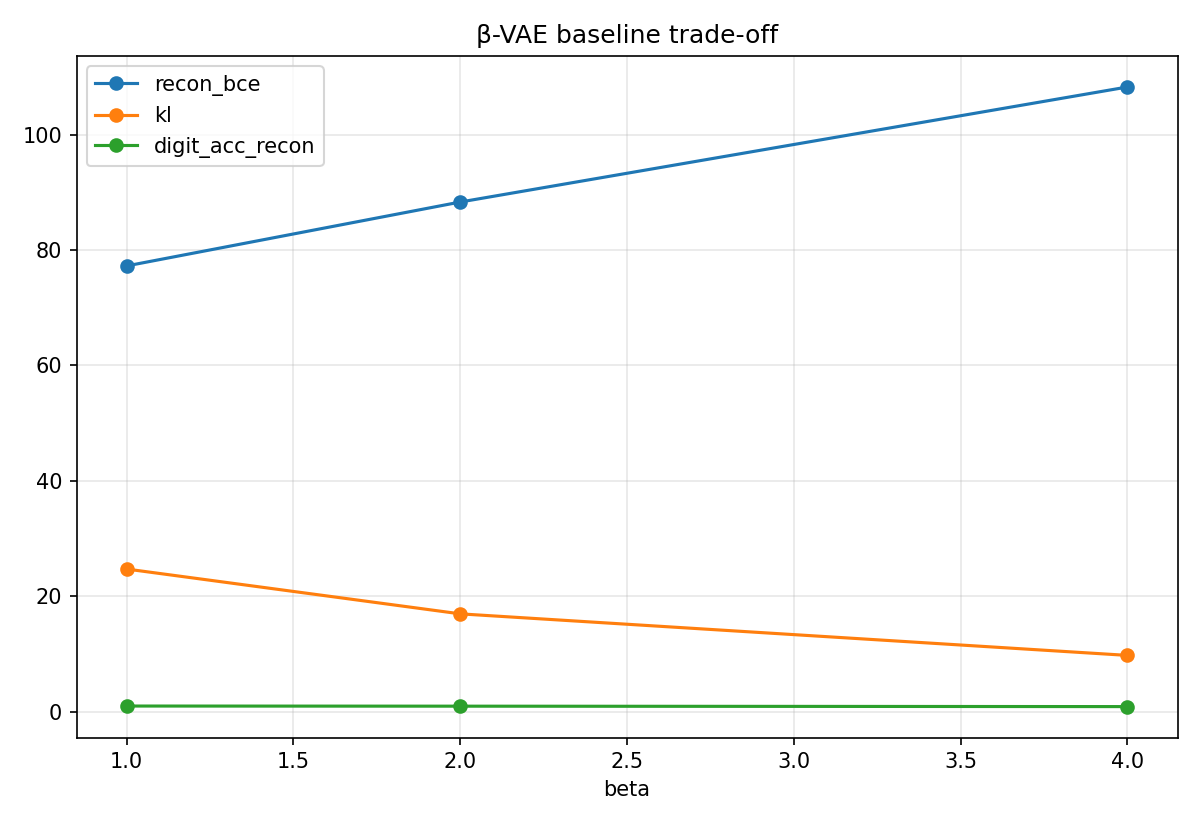

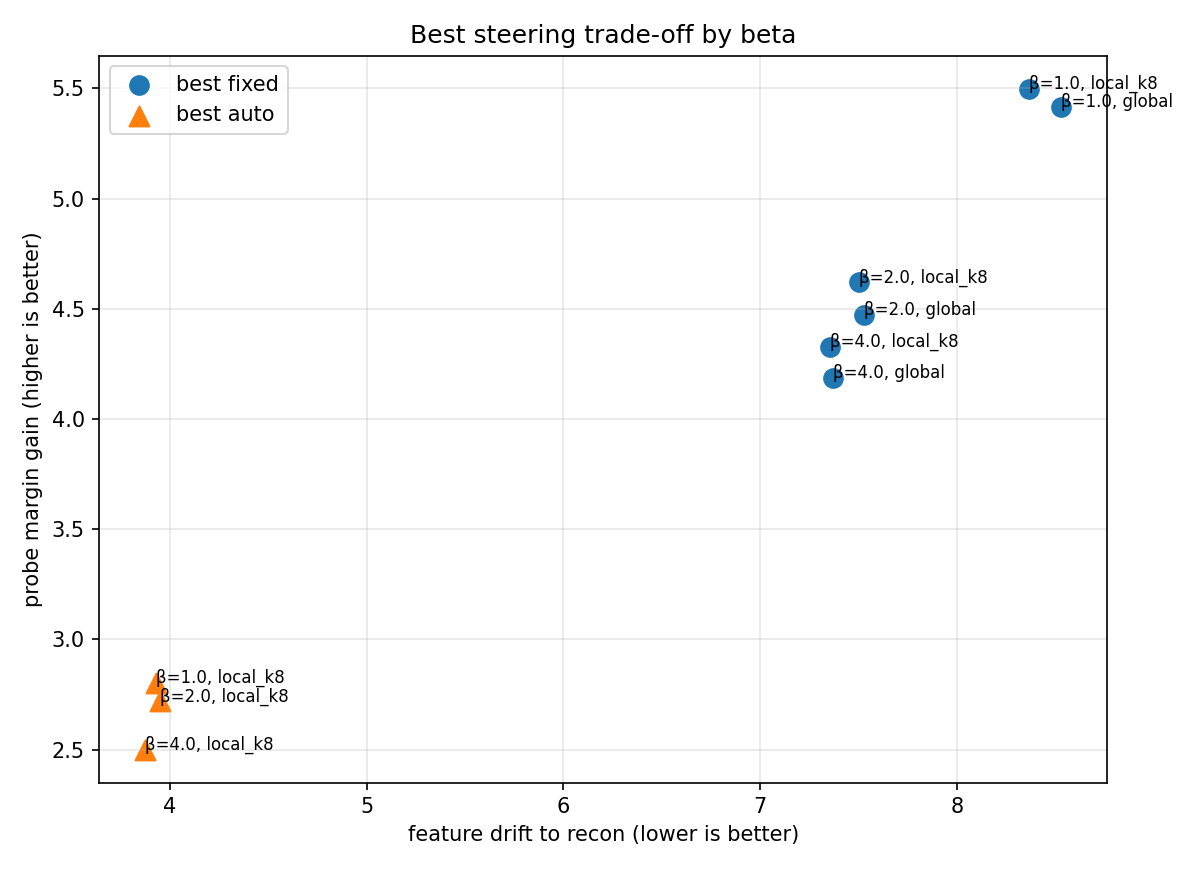

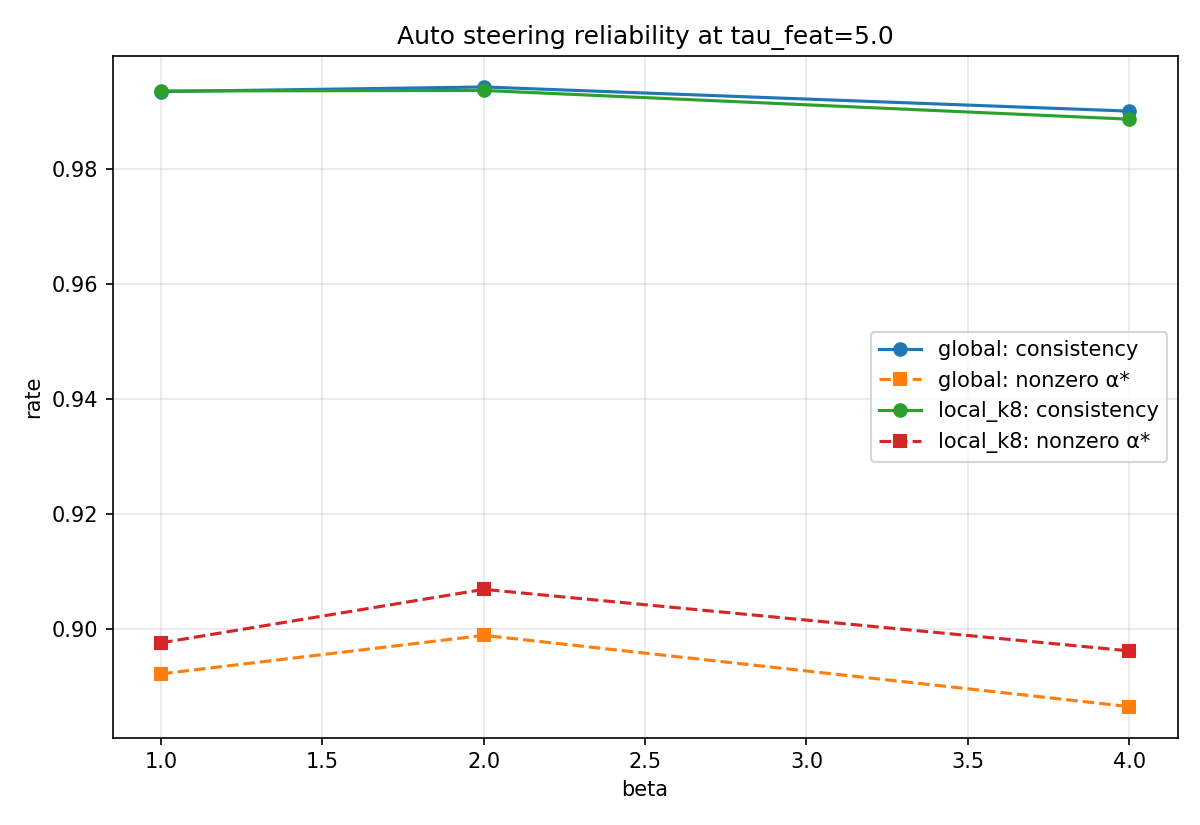

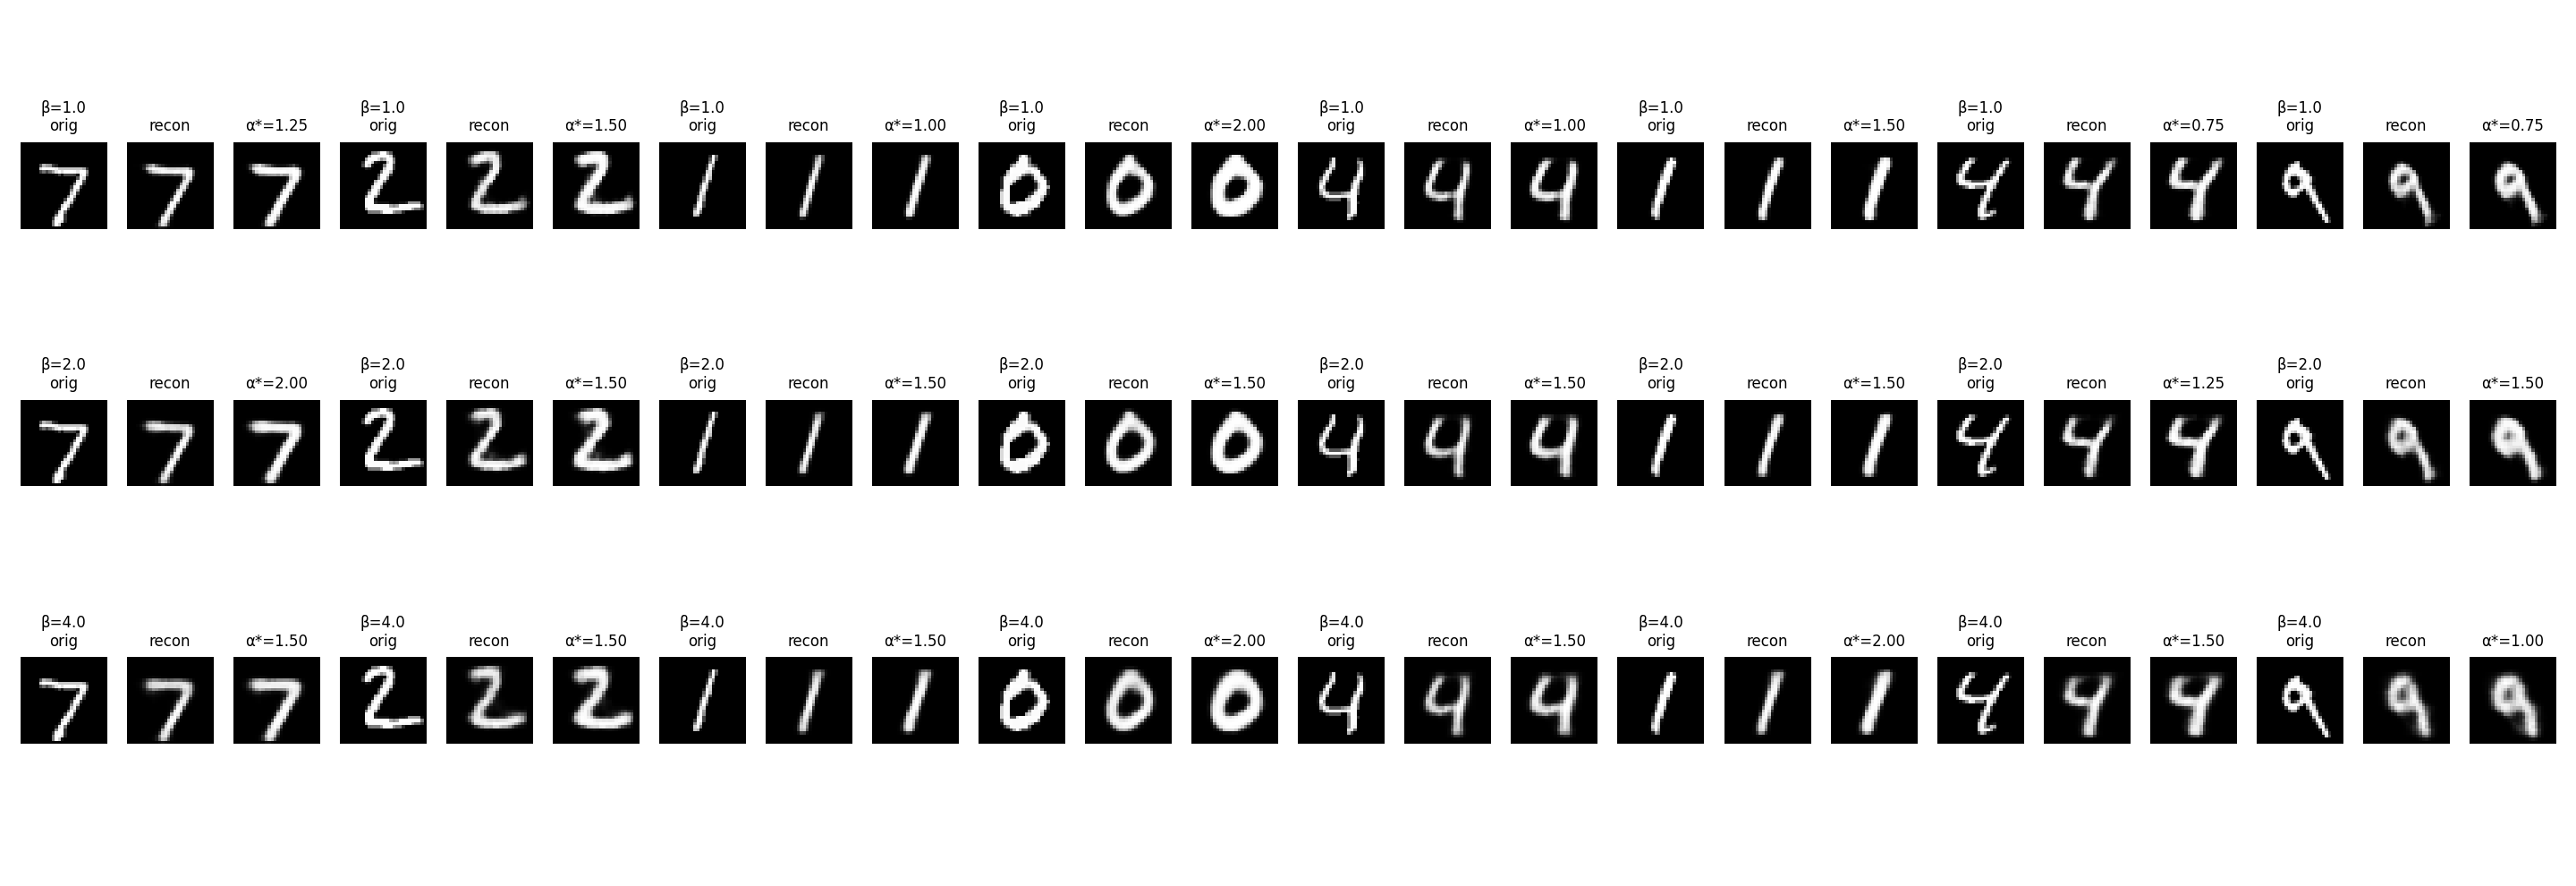

In [13]:
# Optional: show the key plots that were saved to disk
plot_dir = os.path.join(run_dir, "plots")
for name in [
    "beta_recon_summary.png",
    "beta_fixed_vs_auto_tradeoff.png",
    "beta_auto_reliability.png",
    "beta_preview_best_auto.png",
]:
    p = os.path.join(plot_dir, name)
    if os.path.exists(p):
        display(Image(filename=p))